In [ ]:
import requests, pandas as pd


LAT, LON = 23.8103, 90.4125

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": "2023-01-01",
    "end_date": "2025-12-31",   
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Dhaka"
}
data = requests.get(url, params=params).json()
df = pd.DataFrame(data["hourly"])
df["time"] = pd.to_datetime(df["time"])
df = df.rename(columns={
    "temperature_2m": "temperature",
    "relative_humidity_2m": "humidity",
    "precipitation": "precip_mm"
})
df["rain_digital"] = (df["precip_mm"] > 0).astype(int)  
df.to_csv("dhaka_historical_weather.csv", index=False)
print(df.shape)

(26304, 5)


In [ ]:
df.head()
df.describe()

,time,temperature,humidity,precip_mm,rain_digital
count,26304,26304.000000,26304.000000,26304.000000,26304.000000
mean,2024-07-01 23:30:00,26.080988,74.596373,0.198460,0.200160
min,2023-01-01 00:00:00,8.900000,15.000000,0.000000,0.000000
25%,2023-10-01 23:45:00,23.300000,64.000000,0.000000,0.000000
50%,2024-07-01 23:30:00,26.800000,79.000000,0.000000,0.000000
75%,2025-04-01 23:15:00,29.400000,89.000000,0.000000,0.000000
max,2025-12-31 23:00:00,40.900000,100.000000,39.500000,1.000000
std,NaN,5.141758,17.791840,0.973095,0.400127


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df.to_csv('/content/drive/MyDrive/dhaka_historical_weather.csv', index=False)

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, r2_score, confusion_matrix

df = df.sort_values("time").reset_index(drop=True)


df["hour"] = df["time"].dt.hour
df["month"] = df["time"].dt.month

# 3-hour rolling context = 3 rows at hourly resolution
df["temp_roll_3h"] = df["temperature"].rolling(window=3, min_periods=1).mean()
df["humidity_roll_3h"] = df["humidity"].rolling(window=3, min_periods=1).mean()
df["temp_trend"] = df["temperature"].diff().fillna(0)
df["humidity_trend"] = df["humidity"].diff().fillna(0)
df["rain_recent"] = df["rain_digital"].rolling(window=3, min_periods=1).max()


HORIZON = 6  
df["target_temp"] = df["temperature"].shift(-HORIZON)
df["target_humidity"] = df["humidity"].shift(-HORIZON)
df["target_rain"] = (
    df["rain_digital"].shift(-HORIZON).rolling(HORIZON).max() > 0
).astype(int)

df = df.dropna().reset_index(drop=True)
print(f"Rows after feature engineering: {len(df)}")

features = [
    "temperature", "humidity", "hour", "month",
    "temp_roll_3h", "humidity_roll_3h", "temp_trend", "humidity_trend", "rain_recent"
]


X = df[features]


split_idx = int(len(df) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]


y_rain_train, y_rain_test = df["target_rain"].iloc[:split_idx], df["target_rain"].iloc[split_idx:]
rain_clf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rain_clf.fit(X_train, y_rain_train)
rain_preds = rain_clf.predict(X_test)
print("\n--- Rain classification (6h ahead) ---")
print("Accuracy:", accuracy_score(y_rain_test, rain_preds))
print("F1:", f1_score(y_rain_test, rain_preds))
print("Confusion matrix:\n", confusion_matrix(y_rain_test, rain_preds))


naive_rain_pred = df["rain_digital"].iloc[split_idx:]  # "rain in 6h = rain right now"
print("Naive baseline accuracy:", accuracy_score(y_rain_test, naive_rain_pred))


y_temp_train, y_temp_test = df["target_temp"].iloc[:split_idx], df["target_temp"].iloc[split_idx:]
temp_reg = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
temp_reg.fit(X_train, y_temp_train)
temp_preds = temp_reg.predict(X_test)
print("\n--- Temperature regression (6h ahead) ---")
print("MAE:", mean_absolute_error(y_temp_test, temp_preds))
print("R2:", r2_score(y_temp_test, temp_preds))
naive_temp_pred = df["temperature"].iloc[split_idx:]
print("Naive baseline MAE:", mean_absolute_error(y_temp_test, naive_temp_pred))


y_hum_train, y_hum_test = df["target_humidity"].iloc[:split_idx], df["target_humidity"].iloc[split_idx:]
hum_reg = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
hum_reg.fit(X_train, y_hum_train)
hum_preds = hum_reg.predict(X_test)
print("\n--- Humidity regression (6h ahead) ---")
print("MAE:", mean_absolute_error(y_hum_test, hum_preds))
print("R2:", r2_score(y_hum_test, hum_preds))
naive_hum_pred = df["humidity"].iloc[split_idx:]
print("Naive baseline MAE:", mean_absolute_error(y_hum_test, naive_hum_pred))


importances = pd.Series(rain_clf.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- Rain model feature importances ---")
print(importances)


joblib.dump(rain_clf, "rain_model.pkl")
joblib.dump(temp_reg, "temp_model.pkl")
joblib.dump(hum_reg, "humidity_model.pkl")
print("\nModels saved: rain_model.pkl, temp_model.pkl, humidity_model.pkl")

Rows after feature engineering: 26298

--- Rain classification (6h ahead) ---
Accuracy: 0.8547528517110267
F1: 0.8285970685013461
Confusion matrix:
 [[1987  264]
 [ 309 1385]]
Naive baseline accuracy: 0.7700887198986058

--- Temperature regression (6h ahead) ---
MAE: 0.8945262524227722
R2: 0.9208658494256564
Naive baseline MAE: 3.356400506970849

--- Humidity regression (6h ahead) ---
MAE: 5.119254875602377
R2: 0.8386990128676536
Naive baseline MAE: 15.750570342205323

--- Rain model feature importances ---
rain_recent         0.309665
month               0.138704
humidity_roll_3h    0.112732
temperature         0.109451
temp_roll_3h        0.099840
hour                0.085599
humidity            0.065758
temp_trend          0.047925
humidity_trend      0.030325
dtype: float64

Models saved: rain_model.pkl, temp_model.pkl, humidity_model.pkl


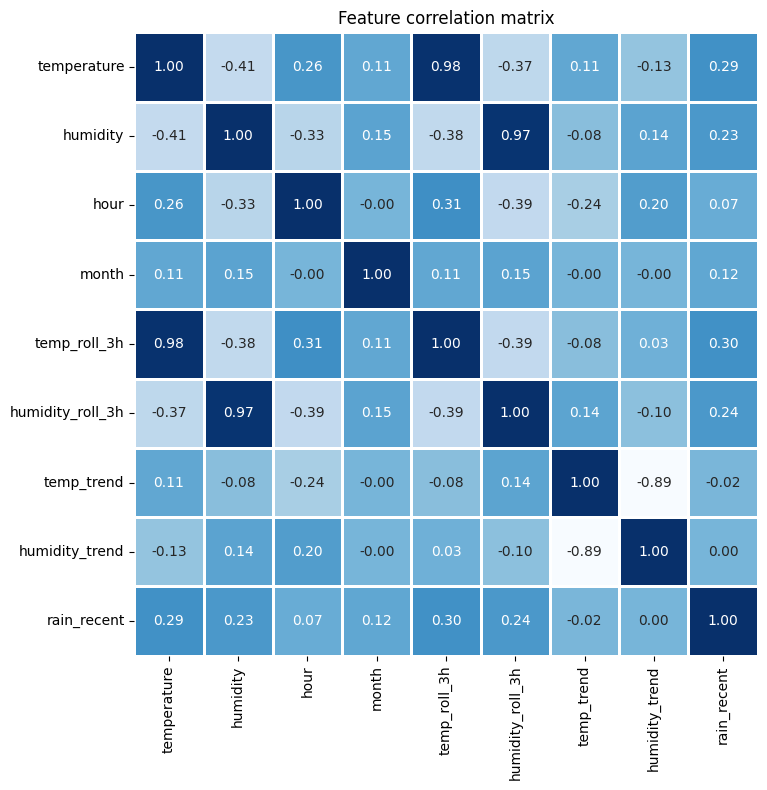

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues",
            square=True, linewidths=1, linecolor="white",
            cbar=False)
plt.title("Feature correlation matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

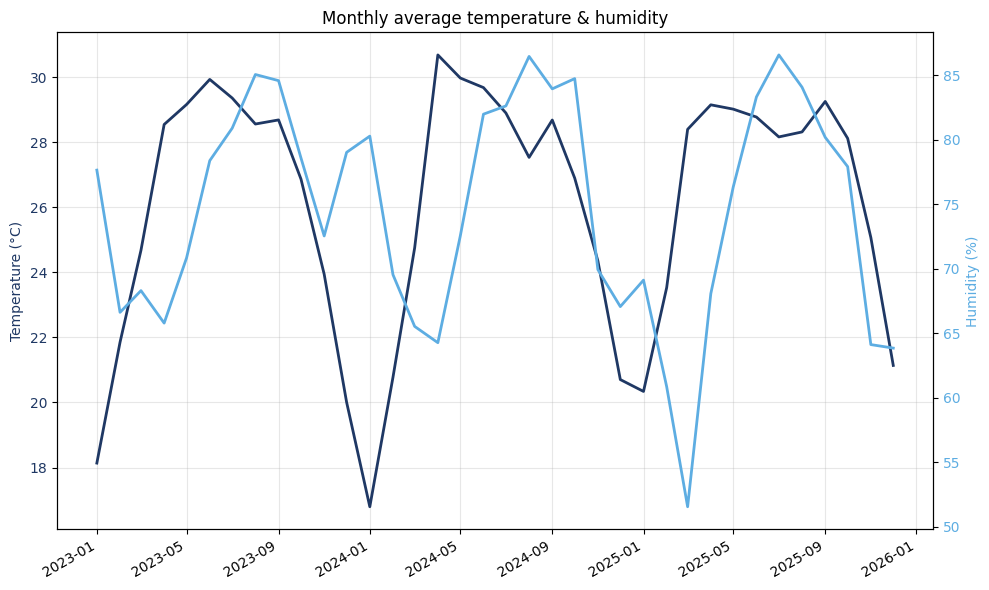

In [7]:
import matplotlib.pyplot as plt

monthly = df.groupby(df["time"].dt.to_period("M")).agg(
    temperature=("temperature", "mean"),
    humidity=("humidity", "mean")
)
monthly.index = monthly.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(10, 6))

color_temp = "#1f3864"   # dark navy
color_hum = "#5dade2"    # light sky blue

ax1.set_xlabel("")
ax1.set_ylabel("Temperature (°C)", color=color_temp)
ax1.plot(monthly.index, monthly["temperature"], color=color_temp, linewidth=2)
ax1.tick_params(axis="y", labelcolor=color_temp)

ax2 = ax1.twinx()
ax2.set_ylabel("Humidity (%)", color=color_hum)
ax2.plot(monthly.index, monthly["humidity"], color=color_hum, linewidth=2)
ax2.tick_params(axis="y", labelcolor=color_hum)

plt.title("Monthly average temperature & humidity")
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()